# Phase 3: High-Frequency ICU Telemetry (Dataset 3)

The Intensive Care Unit (ICU) requires a real-time triage model. 

Patients are continuously monitored across 50 high-frequency physiological metrics. 

You must classify the patient’s state into one of three categories: Stable (Class 0), At-Risk (Class 1), or Critical (Class 2). 

The core difficulty lies in the “Stable” class, which consists of two vastly different physiological states:
1. patients who are awake and resting, 

2. patients who are in a state of chemically induced deep sleep.

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.stats import multivariate_normal

In [2]:
dataset = np.genfromtxt("../PRNN_2026_A1_data/dataset_3.csv", delimiter=",", dtype=float, skip_header=1, filling_values=np.nan)

print(dataset.shape)

print(np.isnan(dataset).any())

(20000, 51)
False


In [3]:
x = dataset[:, :-1]
y = dataset[:, -1:]

print(x.shape, y.shape)

(20000, 50) (20000, 1)


In [4]:
num_features = x.shape[1]
num_data = x.shape[0]
print(num_data, num_features)

20000 50


## 3.5 Vectorized Logistic Regression:
Filter Dataset 3 to include only Class 1 and Class 2.

Implement binary Logistic Regression with L2 regularization using gradient descent. Plot
the learning curve. 

Demonstrate empirically how the curve behaves when you increase
the learning rate to a point that violates the Lipschitz smoothness condition.

In [5]:
# Filter Dataset 3 to include only Class 1 and Class 2
mask = ((y == 1) | (y == 2)).flatten()
x_filtered = x[mask]
y_filtered = y[mask]

# Remap labels to 0 and 1 for binary classification (Class 1 -> 0, Class 2 -> 1)
y_filtered = y_filtered - 1

print(f"Original shape: {x.shape}, {y.shape}")
print(f"Filtered shape: {x_filtered.shape}, {y_filtered.shape}")

Original shape: (20000, 50), (20000, 1)
Filtered shape: (10000, 50), (10000, 1)


In [7]:
print(x[5, 0], x_filtered[5, 0])

-3.323796690706841 -2.611599190019413


In [19]:
def sigmoid(z):
    z = np.clip(z, -500, 500) # clip to avoid overflow
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, w, lamda):
    m = X.shape[0]
    epsilon = 1e-15 # to avoid log(0)

    h = sigmoid(X @ w)

    bce_cost = - (1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    reg_cost = lamda * (0.5 / m) * np.sum(w[1:]**2) 

    return bce_cost + reg_cost

def gradient_descent(X, y, w_init, lamda, lr = 0.001, epochs = 10):
    m = X.shape[0]
    w = w_init.copy()
    loss_history = []
    
    for i in range(epochs):
        cost = compute_cost(X, y, w, lamda)
        loss_history.append(cost)
        print(f"Epoch {i} Loss: {cost}")
        
        h = sigmoid(X @ w)
        bce_grad = (1/m) * X.T @ (h - y)
        
        # Regularization gradient
        reg_grad = (lamda / m) * w
        reg_grad[0] = 0 # skipping the bias term
        grad = bce_grad + reg_grad
        
        w = w - lr * grad
        
    return w, loss_history

In [26]:
X_augmented = np.hstack((np.ones((x_filtered.shape[0], 1)), x_filtered))
w_init = np.zeros((X_augmented.shape[1], 1))

/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_88711/2667605369.py:9: RuntimeWarning: divide by zero encountered in matmul
  h = sigmoid(X @ w)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_88711/2667605369.py:9: RuntimeWarning: overflow encountered in matmul
  h = sigmoid(X @ w)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_88711/2667605369.py:9: RuntimeWarning: invalid value encountered in matmul
  h = sigmoid(X @ w)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_88711/2667605369.py:26: RuntimeWarning: divide by zero encountered in matmul
  h = sigmoid(X @ w)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_88711/2667605369.py:26: RuntimeWarning: overflow encountered in matmul
  h = sigmoid(X @ w)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_88711/2667605369.py:26: RuntimeWarning: invalid value encountered in matmul
  h = sigmoid(X @ w)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_88711/2667605369

Epoch 0 Loss: 0.6931471805599435
Epoch 1 Loss: 0.6662633583356316
Epoch 2 Loss: 0.6409328827666003
Epoch 3 Loss: 0.6170622250406078
Epoch 4 Loss: 0.5945613081671112
Epoch 5 Loss: 0.5733439226808973
Epoch 6 Loss: 0.5533280062647362
Epoch 7 Loss: 0.5344358072437777
Epoch 8 Loss: 0.516593951479373
Epoch 9 Loss: 0.49973343095240275
Epoch 10 Loss: 0.4837895305867914
Epoch 11 Loss: 0.46870170786999793
Epoch 12 Loss: 0.45441343776365367
Epoch 13 Loss: 0.4408720333933178
Epoch 14 Loss: 0.4280284511444998
Epoch 15 Loss: 0.4158370871196521
Epoch 16 Loss: 0.40425557044812943
Epoch 17 Loss: 0.39324455768998345
Epoch 18 Loss: 0.382767531524698
Epoch 19 Loss: 0.3727906060502197
Epoch 20 Loss: 0.36328234031506895
Epoch 21 Loss: 0.35421356114500585
Epoch 22 Loss: 0.34555719588437334
Epoch 23 Loss: 0.3372881153310515
Epoch 24 Loss: 0.32938298688522255
Epoch 25 Loss: 0.3218201377403699
Epoch 26 Loss: 0.3145794278068791
Epoch 27 Loss: 0.30764213196311174
Epoch 28 Loss: 0.30099083116664044
Epoch 29 Loss: 

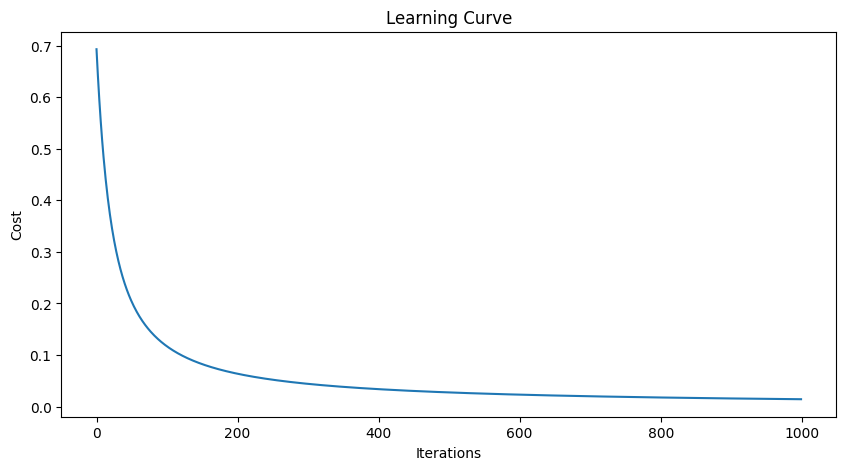

In [37]:
lamda = 0.1
total_epochs = 1000
lr = 0.0001

w, loss_history = gradient_descent(X_augmented, y_filtered, w_init, lamda, lr, total_epochs)

plt.figure(figsize=(10, 5))
plt.plot(range(total_epochs), loss_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Learning Curve')
plt.show()

/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_88711/2667605369.py:9: RuntimeWarning: divide by zero encountered in matmul
  h = sigmoid(X @ w)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_88711/2667605369.py:9: RuntimeWarning: overflow encountered in matmul
  h = sigmoid(X @ w)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_88711/2667605369.py:9: RuntimeWarning: invalid value encountered in matmul
  h = sigmoid(X @ w)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_88711/2667605369.py:26: RuntimeWarning: divide by zero encountered in matmul
  h = sigmoid(X @ w)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_88711/2667605369.py:26: RuntimeWarning: overflow encountered in matmul
  h = sigmoid(X @ w)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_88711/2667605369.py:26: RuntimeWarning: invalid value encountered in matmul
  h = sigmoid(X @ w)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_88711/2667605369

Epoch 0 Loss: 0.6931471805599435
Epoch 1 Loss: 2.1827258589080905
Epoch 2 Loss: 2.1809800274571014
Epoch 3 Loss: 2.1792355923919398
Epoch 4 Loss: 2.177492552595721
Epoch 5 Loss: 2.175750906952453
Epoch 6 Loss: 2.1740106543470357
Epoch 7 Loss: 2.172271793665263
Epoch 8 Loss: 2.170534323793818
Epoch 9 Loss: 2.168798243620275
Epoch 10 Loss: 2.167063552033097
Epoch 11 Loss: 2.165330247921639
Epoch 12 Loss: 2.1635983301761414
Epoch 13 Loss: 2.1618677976877336
Epoch 14 Loss: 2.160138649348431
Epoch 15 Loss: 2.158410884051136
Epoch 16 Loss: 2.1566845006896367
Epoch 17 Loss: 2.154959498158605
Epoch 18 Loss: 2.153235875353598
Epoch 19 Loss: 2.151513631171055
Epoch 20 Loss: 2.149792764508299
Epoch 21 Loss: 2.1480732742635347
Epoch 22 Loss: 2.1463551593358483
Epoch 23 Loss: 2.1446384186252043
Epoch 24 Loss: 2.1429230510324513
Epoch 25 Loss: 2.1412090554593135
Epoch 26 Loss: 2.1394964308083955
Epoch 27 Loss: 2.1377851759831774
Epoch 28 Loss: 2.1360752898880184
Epoch 29 Loss: 2.1343667714281547
Epo

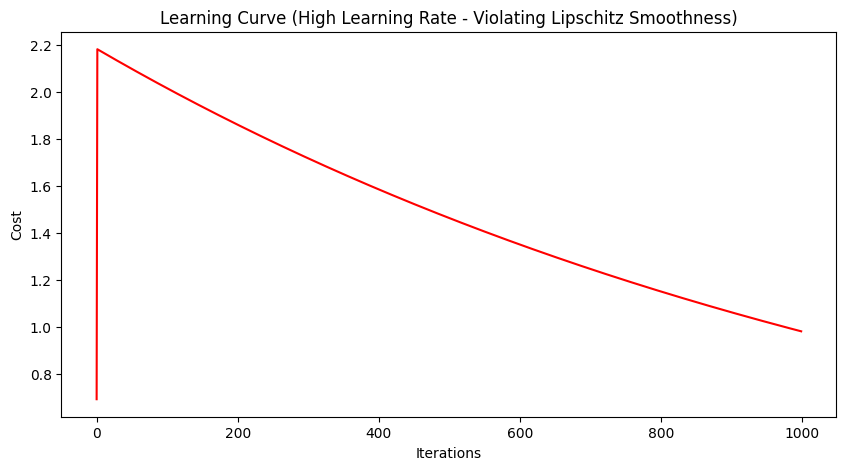

In [46]:
high_learning_rate = 40.0

w_highw, loss_history_high = gradient_descent(X_augmented, y_filtered, w_init, lamda, high_learning_rate, total_epochs)

plt.figure(figsize=(10, 5))
plt.plot(range(total_epochs_high), loss_history_high, color='red')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Learning Curve (High Learning Rate - Violating Lipschitz Smoothness)')
plt.show()


## 3.6 GMM Initialization & The E-Step:
Implement the EM algorithm for a Gaussian Mixture Model. 

Initialize a GMM with K = 4 on Dataset 3 using random means and spherical covariances. 

Execute exactly one E-step and one M-step. 

Report the initial marginal log-likelihood of the dataset, and the exact log-likelihood after this single iteration.

In [47]:
np.random.seed(42)
K = 4
N, D = x.shape

# Initialize pi, mu, Sigma
pi = np.ones(K) / K

# Random means
random_indices = np.random.choice(N, K, replace=False)
mu = x[random_indices, :]

# Spherical covariances: Sigma_k = sigma^2 * I
# we can initialize sigma to the mean variance across all dimensions
sigma_squared = np.var(x, axis=0).mean()
Sigma = np.array([sigma_squared * np.eye(D) for _ in range(K)])

In [48]:
def e_step(X, pi, mu, Sigma, K):
    N = X.shape[0]
    log_densities = np.zeros((N, K))
    for k in range(K):
        # add small epsilon to diagonal for strict positive definiteness
        cov_k = Sigma[k] + 1e-6 * np.eye(Sigma[k].shape[0])
        log_densities[:, k] = np.log(pi[k] + 1e-15) + multivariate_normal.logpdf(X, mean=mu[k], cov=cov_k)
        
    # log-sum-exp trick to avoid numerical underflow in 50D
    max_log_densities = np.max(log_densities, axis=1, keepdims=True)
    exp_log_densities = np.exp(log_densities - max_log_densities)
    sum_exp_log_densities = np.sum(exp_log_densities, axis=1, keepdims=True)
    
    log_marginal_densities = np.squeeze(max_log_densities) + np.squeeze(np.log(sum_exp_log_densities + 1e-15))
    log_likelihood = np.sum(log_marginal_densities)
    
    # Compute responsibilities
    gamma = exp_log_densities / (sum_exp_log_densities + 1e-15)
    
    return log_likelihood, gamma

def m_step(X, gamma, K):
    N = X.shape[0]
    D = X.shape[1]
    
    N_k = np.sum(gamma, axis=0)
    pi_new = N_k / N
    
    mu_new = np.zeros((K, D))
    Sigma_new = np.zeros((K, D, D))
    
    for k in range(K):
        # Update mean
        mu_new[k] = np.sum(gamma[:, k:k+1] * X, axis=0) / (N_k[k] + 1e-15)
        
        # Update covariance
        diff = X - mu_new[k]
        Sigma_new[k] = np.dot(gamma[:, k] * diff.T, diff) / (N_k[k] + 1e-15)
        # Add regularizer to ensure pos-definiteness for next steps
        Sigma_new[k] += 1e-6 * np.eye(D)
        
    return pi_new, mu_new, Sigma_new

In [51]:
# 1. Initial State / E-step
initial_ll, gamma = e_step(x, pi, mu, Sigma, K)
print(f"Initial marginal log-likelihood: {initial_ll:.2f}")

# 2. M-step
pi, mu, Sigma = m_step(x, gamma, K)

# 3. E-step again to compute log-likelihood after one full iteration
new_ll, _ = e_step(x, pi, mu, Sigma, K)
print(f"Marginal log-likelihood after one iteration: {new_ll:.2f}")

Initial marginal log-likelihood: -2691464.25
Marginal log-likelihood after one iteration: -1718835.45


/Users/bitupan_arandhara/Desktop/Study/IISc/PRNN/prnn_env/lib/python3.10/site-packages/scipy/stats/_covariance.py:630: RuntimeWarning: divide by zero encountered in matmul
  return x @ self._LP
/Users/bitupan_arandhara/Desktop/Study/IISc/PRNN/prnn_env/lib/python3.10/site-packages/scipy/stats/_covariance.py:630: RuntimeWarning: overflow encountered in matmul
  return x @ self._LP
/Users/bitupan_arandhara/Desktop/Study/IISc/PRNN/prnn_env/lib/python3.10/site-packages/scipy/stats/_covariance.py:630: RuntimeWarning: invalid value encountered in matmul
  return x @ self._LP


## 3.7 EM Convergence & Crashes:
Run your GMM on Dataset 3 for K = 2, 4, 6. 

Plot the
log-likelihood over iterations to empirically verify monotonic convergence. 

Programmatically force one of the covariance matrices to zero variance mid-training, and document
the exact Python error that breaks the Multivariate Normal PDF computation

In [58]:
def run_gmm(X, K, max_iters=50, tol=1e-4, force_crash=False):
    N, D = X.shape
    np.random.seed(42)
    pi = np.ones(K) / K
    random_indices = np.random.choice(N, K, replace=False)
    mu = X[random_indices, :]
    sigma_squared = np.var(X, axis=0).mean()
    Sigma = np.array([sigma_squared * np.eye(D) for _ in range(K)])
    
    log_likelihoods = []
    for i in range(max_iters):
        if force_crash and i == 2: # Force crash mid-training
            # Force one covariance matrix to zero variance
            Sigma[0] = np.zeros((D, D))
            
        try:
            ll, gamma = e_step(X, pi, mu, Sigma, K)
            log_likelihoods.append(ll)
            pi, mu, Sigma = m_step(X, gamma, K)
            
            if i > 0 and ll - log_likelihoods[-2] < tol:
                break
        except Exception as e:
            if force_crash:
                import traceback
                error_details = traceback.format_exc()
                return log_likelihoods, (type(e).__name__, str(e), error_details)
            raise e
            
    return log_likelihoods, None

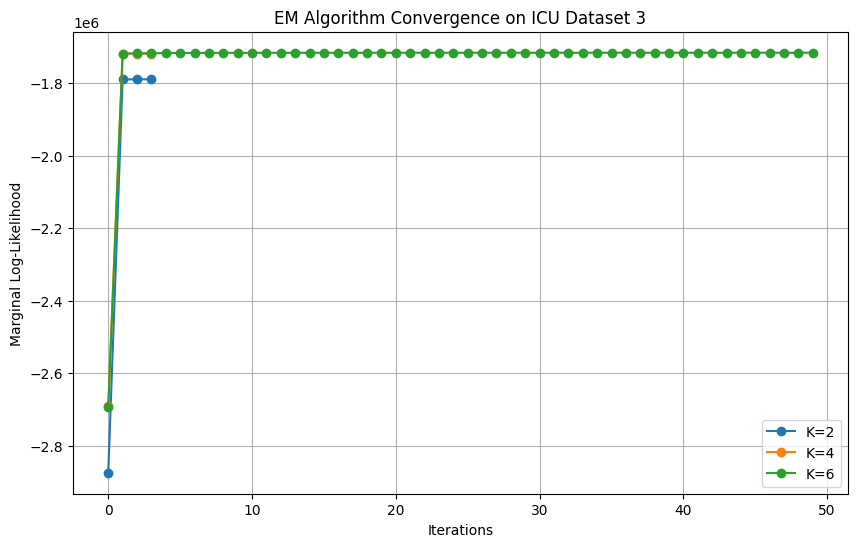

In [59]:
# 1. Run GMM for K = 2, 4, 6
plt.figure(figsize=(10, 6))
for k in [2, 4, 6]:
    lls, _ = run_gmm(x, K=k)
    plt.plot(range(len(lls)), lls, marker='o', label=f'K={k}')

plt.xlabel('Iterations')
plt.ylabel('Marginal Log-Likelihood')
plt.title('EM Algorithm Convergence on ICU Dataset 3')
plt.legend()
plt.grid(True)
plt.show()

In [60]:
# 2. To force one covariance matrix to zero variance
_, crash_error = run_gmm(x, K=2, force_crash=True)
if crash_error:
    err_type, err_msg, _ = crash_error
    print(f"\n--- CRASH DOCUMENTATION ---")
    print(f"Error Type : {err_type}")
    print(f"Error Msg  : {err_msg}")
    print(f"Reason     : Multivariate Normal PDF computation expects a positive definitive covariance matrix.\n"
          f"             When we force a covariance matrix to have zero variance, it becomes singular\n"
          f"             (determinant is 0), meaning its inverse cannot be computed, violating the mathematical\n"
          f"             requirements of the Gaussian distribution.")

## 3.8 Decision Boundaries: 
Extract the first two dimensions of Dataset 3. 

Train a GMM
(K = 3) on this subset. 

Plot a dense grid of the resulting Bayes Optimal decision boundaries, and overlay the contour lines of the learned Gaussian covariance matrices on top of
the data scatter plot

## 3.9 SVM with Slack KKT Verification:
Filter Dataset 3 for Class 1 and Class 2. Implement the soft-margin SVM dual and train it with C = 1.0. 

Programmatically evaluate your optimized μ array to verify the KKT conditions. 

Print the index and μ value of: 
(a) one point strictly inside the margin, 
(b) one point exactly on the margin boundary, and 
(c) one point safely classified outside the margin.

## 3.10 Mercer’s Condition: 
Implement the RBF (Gaussian) Kernel function. 

Compute the full
N × N Kernel matrix K for a 1,000-sample subset of Dataset 3. 
Compute the eigenvalues
of K. 

Show programmatically that all eigenvalues are non-negative, verifying that your
kernel matrix is Positive Semi-Definite

## 3.11 Hyperparameter Topography: 
Write a script to perform a grid search over C ∈
{0.1, 1, 10, 100} and σ ∈ {0.001, 0.01, 0.1, 1, 10} for your RBF SVM. 

Generate a 2D heatmap
plot of the validation accuracy across this grid. 

Identify the precise hyperparameter coordinate (C, σ) where the model exhibits the most severe overfitting.